In [1]:
import os
import shutil
from glob import glob

# Correct local dataset path (Windows)
dataset_path = r"C:\Users\AUSTCSE4090\Desktop\CHASEDB\CHASEDB1\CHASEDB1\CHASEDB1"

# Destination folders
images_folder = r"C:\Users\AUSTCSE4090\Desktop\CHASEDB\processed\CHASEDB1_images"
masks_folder = r"C:\Users\AUSTCSE4090\Desktop\CHASEDB\processed\CHASEDB1_1stHO"

# Create folders if they don't exist
os.makedirs(images_folder, exist_ok=True)
os.makedirs(masks_folder, exist_ok=True)

# Copy all images (.jpg)
images = glob(os.path.join(dataset_path, "*.jpg"))
for img in images:
    shutil.copy(img, images_folder)

# Copy only _1stHO masks
masks = glob(os.path.join(dataset_path, "*_1stHO.png"))
for mask in masks:
    shutil.copy(mask, masks_folder)

print(f"Copied {len(images)} images to {images_folder}")
print(f"Copied {len(masks)} masks to {masks_folder}")


Copied 28 images to C:\Users\AUSTCSE4090\Desktop\CHASEDB\processed\CHASEDB1_images
Copied 28 masks to C:\Users\AUSTCSE4090\Desktop\CHASEDB\processed\CHASEDB1_1stHO


C:\Users\AUSTCSE4090\anaconda3\envs\py310\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Train images: 20
Test images: 8
Datasets ready: train_ds, test_ds
Total patches: 121


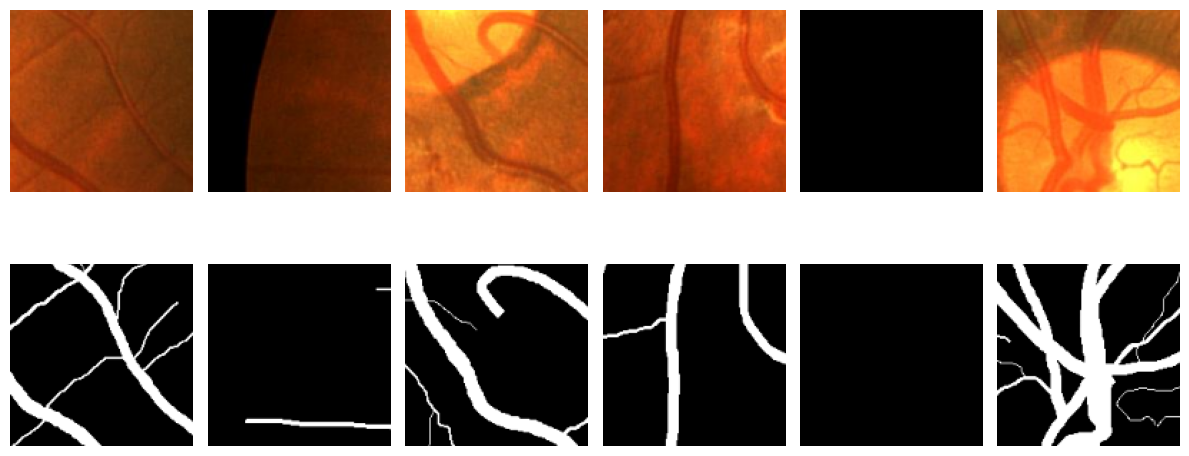

In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf
import albumentations as A
import matplotlib.pyplot as plt
import random

# ================= PATHS =================
IMG_DIR = r"C:\Users\AUSTCSE4090\Desktop\CHASEDB\processed\CHASEDB1_images"
MASK_DIR = r"C:\Users\AUSTCSE4090\Desktop\CHASEDB\processed\CHASEDB1_1stHO"

# ================= CONSTANTS =================
RESIZE_SIZE = 768  # Resize original images to 768x768
IMG_SIZE = 128     # Patch size
OVERLAP = 0.5
BATCH_SIZE = 8

# ================= AUGMENTATION =================
augmenter = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=15,
        border_mode=cv2.BORDER_REFLECT,
        p=0.5
    ),
    A.RandomBrightnessContrast(p=0.3),
])

# ================= FUNCTIONS =================
def is_valid_patch(mask, threshold=0.01):
    return np.count_nonzero(mask) / mask.size > threshold

def extract_patches(img, mask, patch_size=IMG_SIZE, overlap=OVERLAP, skip_empty=True):
    stride = int(patch_size * (1 - overlap))
    patches_img = []
    patches_mask = []
    H, W = img.shape[:2]

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            p_img = img[y:y+patch_size, x:x+patch_size]
            p_mask = mask[y:y+patch_size, x:x+patch_size]

            if skip_empty and not is_valid_patch(p_mask):
                continue

            patches_img.append(p_img)
            patches_mask.append(p_mask)

    return patches_img, patches_mask

def load_image_mask_paths(image_dir, mask_dir):
    image_files = sorted([
        os.path.join(image_dir, f)
        for f in os.listdir(image_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    mask_files = sorted([
        os.path.join(mask_dir, f)
        for f in os.listdir(mask_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    return image_files, mask_files

def generator(image_paths, mask_paths, augment=True, skip_empty=True):
    for img_path, mask_path in zip(image_paths, mask_paths):

        # Read images
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Resize to 768x768
        img = cv2.resize(img, (RESIZE_SIZE, RESIZE_SIZE))
        mask = cv2.resize(mask, (RESIZE_SIZE, RESIZE_SIZE))

        # Extract patches
        patches_img, patches_mask = extract_patches(
            img, mask, IMG_SIZE, OVERLAP, skip_empty
        )

        for p_img, p_mask in zip(patches_img, patches_mask):

            if augment:
                data = augmenter(image=p_img, mask=p_mask)
                p_img, p_mask = data["image"], data["mask"]

            p_img = p_img.astype(np.float32) / 255.0
            p_mask = np.expand_dims(p_mask.astype(np.float32) / 255.0, axis=-1)

            yield p_img, p_mask

# ================= LOAD PATHS =================
all_images, all_masks = load_image_mask_paths(IMG_DIR, MASK_DIR)

# ===== Manual split: FIRST 20 → train, LAST 8 → test =====
train_images = all_images[:20]
train_masks  = all_masks[:20]

test_images  = all_images[20:]
test_masks   = all_masks[20:]

print(f"Train images: {len(train_images)}")
print(f"Test images: {len(test_images)}")

# ================= TF.DATA DATASETS =================
train_ds = tf.data.Dataset.from_generator(
    lambda: generator(train_images, train_masks, augment=True, skip_empty=True),
    output_signature=(
        tf.TensorSpec((IMG_SIZE, IMG_SIZE, 3), tf.float32),
        tf.TensorSpec((IMG_SIZE, IMG_SIZE, 1), tf.float32)
    )
).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_generator(
    lambda: generator(test_images, test_masks, augment=False, skip_empty=False),
    output_signature=(
        tf.TensorSpec((IMG_SIZE, IMG_SIZE, 3), tf.float32),
        tf.TensorSpec((IMG_SIZE, IMG_SIZE, 1), tf.float32)
    )
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Datasets ready: train_ds, test_ds")

# ================= VISUALIZATION =================
def visualize_patches(img_path, mask_path, num_samples=6):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Resize for visualization
    img = cv2.resize(img, (RESIZE_SIZE, RESIZE_SIZE))
    mask = cv2.resize(mask, (RESIZE_SIZE, RESIZE_SIZE))

    patches_img, patches_mask = extract_patches(
        img, mask, patch_size=IMG_SIZE, overlap=OVERLAP, skip_empty=False
    )

    print(f"Total patches: {len(patches_img)}")

    indices = random.sample(range(len(patches_img)), min(num_samples, len(patches_img)))

    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(indices):
        plt.subplot(2, num_samples, i+1)
        plt.imshow(patches_img[idx])
        plt.axis("off")

        plt.subplot(2, num_samples, i+1+num_samples)
        plt.imshow(patches_mask[idx], cmap="gray")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Example visualization
visualize_patches(train_images[0], train_masks[0])


In [3]:
# ================= COUNT TRAINING & TEST PATCHES =================
def count_patches(image_paths, mask_paths, patch_size=IMG_SIZE, overlap=OVERLAP, skip_empty=True):
    total_patches = 0
    for img_path, mask_path in zip(image_paths, mask_paths):

        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        patches_img, patches_mask = extract_patches(img, mask, patch_size, overlap, skip_empty)
        total_patches += len(patches_img)

    return total_patches


train_patch_count = count_patches(train_images, train_masks, skip_empty=True)
test_patch_count  = count_patches(test_images, test_masks, skip_empty=False)

print(f"Total training patches: {train_patch_count}")
print(f"Total test patches: {test_patch_count}")


Total training patches: 3316
Total test patches: 1568


In [5]:
import tensorflow as tf
from tensorflow.keras import backend as K

def confusion_elements(y_true, y_pred):
    """Helper to calculate TP, TN, FP, FN"""
    y_pred = K.round(y_pred)
    y_true = K.round(y_true)
    TP = K.sum(y_true * y_pred)
    TN = K.sum((1 - y_true) * (1 - y_pred))
    FP = K.sum((1 - y_true) * y_pred)
    FN = K.sum(y_true * (1 - y_pred))
    return TP, TN, FP, FN

# Sensitivity (Recall)
def sensitivity(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return TP / (TP + FN + K.epsilon())

# Specificity
def specificity(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return TN / (TN + FP + K.epsilon())

# Accuracy
def accuracy(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return (TP + TN) / (TP + TN + FP + FN + K.epsilon())

# Precision
def precision(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return TP / (TP + FP + K.epsilon())

# F1-score
def f1_score(y_true, y_pred):
    prec = precision(y_true, y_pred)
    rec = sensitivity(y_true, y_pred)
    return 2 * ((prec * rec) / (prec + rec + K.epsilon()))

# AUC (use Keras built-in metric)
auc = tf.keras.metrics.AUC(name='auc')


import tensorflow as tf
import tensorflow.keras.backend as K

smooth = 1e-6

def iou(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(K.round(y_pred), tf.float32)  # Round to binary
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(K.round(y_pred))  # Round predictions to binary
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


In [8]:
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, MaxPooling2D, Activation, BatchNormalization, concatenate, multiply, add
from tensorflow.keras.models import Model

def attention_gate(gating, skip_connection, filters):
    g_conv = Conv2D(filters, (1, 1), padding='same')(gating)
    x_conv = Conv2D(filters, (1, 1), padding='same')(skip_connection)

    add_xg = add([g_conv, x_conv])
    act_xg = Activation('relu')(add_xg)

    psi = Conv2D(1, (1, 1), padding='same')(act_xg)
    psi = Activation('sigmoid')(psi)

    return multiply([skip_connection, psi])

def conv_block(x, filters):
    x = Conv2D(filters, (3, 3), padding='same')(x)
    x = Activation('relu')(x)
    x = BatchNormalization()(x)

    x = Conv2D(filters, (3, 3), padding='same')(x)
    x = Activation('relu')(x)
    x = BatchNormalization()(x)
    return x

def encoder_block(x, filters):
    c = conv_block(x, filters)
    p = MaxPooling2D((2, 2))(c)
    return p, c

def decoder_block(x, skip, filters):
    x = Conv2DTranspose(filters, (2, 2), strides=2, padding='same')(x)
    x = concatenate([x, skip])
    x = conv_block(x, filters)
    return x

def get_attention_unet(input_shape=(128,128,3), start_filters=32, num_classes=1):
    inputs = Input(input_shape)

    # Encoder
    p0, c0 = encoder_block(inputs, start_filters)
    p1, c1 = encoder_block(p0, start_filters * 2)
    p2, c2 = encoder_block(p1, start_filters * 4)
    p3, c3 = encoder_block(p2, start_filters * 8)

    # Bottleneck
    bn = conv_block(p3, start_filters * 16)

    # Decoder + Attention
    g3 = decoder_block(bn, c3, start_filters * 8)
    a3 = attention_gate(g3, c3, start_filters * 8)

    g2 = decoder_block(a3, c2, start_filters * 4)
    a2 = attention_gate(g2, c2, start_filters * 4)

    g1 = decoder_block(a2, c1, start_filters * 2)
    a1 = attention_gate(g1, c1, start_filters * 2)

    g0 = decoder_block(a1, c0, start_filters)

    outputs = Conv2D(num_classes, (1, 1), activation='sigmoid')(g0)

    model = Model(inputs, outputs)
    return model

# Build model
attention_unet_model = get_attention_unet()
attention_unet_model.summary()


Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_56 (Conv2D)             (None, 128, 128, 32  896         ['input_3[0][0]']                
                                )                                                                 
                                                                                                  
 activation_48 (Activation)     (None, 128, 128, 32  0           ['conv2d_56[0][0]']              
                                )                                                           

In [9]:
import tensorflow as tf
from tensorflow.keras import backend as K

# ----------------------------------
# Tversky Index
# ----------------------------------
def tversky(y_true, y_pred, alpha=0.7, beta=0.3):
    # numerical stability
    y_pred = K.clip(y_pred, 1e-7, 1 - 1e-7)

    y_true_pos = K.flatten(y_true)
    y_pred_pos = K.flatten(y_pred)
    

    true_pos = K.sum(y_true_pos * y_pred_pos)
    false_neg = K.sum(y_true_pos * (1 - y_pred_pos))
    false_pos = K.sum((1 - y_true_pos) * y_pred_pos)

    return (true_pos + 1e-6) / (
        true_pos + alpha * false_neg + beta * false_pos + 1e-6
    )


# ----------------------------------
# Focal Tversky Loss
# ----------------------------------
def focal_tversky_loss(y_true, y_pred, gamma=0.75):
    tv = tversky(y_true, y_pred)
    return K.pow((1 - tv), gamma)


# ----------------------------------
# Hybrid Loss (Recommended)
# ----------------------------------
def hybrid_loss(y_true, y_pred):
    ft = focal_tversky_loss(y_true, y_pred)
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    return 0.7 * ft + 0.3 * bce


In [10]:
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.optimizers import Adam


# Define Adam optimizer with an initial learning rate
initial_lr = 1e-4
optimizer = Adam(learning_rate=initial_lr)


def lr_schedule(epoch, lr):
    if epoch < 5:  # Warmup phase
        return lr * 1.5  # Increase LR to stabilize training
    elif epoch < 30:
        return lr * 0.98  # Gradual decay
    else:
        return lr * 0.95  # Final stabilization

lr_scheduler = LearningRateScheduler(lr_schedule)

In [11]:
from tensorflow.keras.losses import BinaryCrossentropy
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=9, restore_best_weights=True),
    lr_scheduler
    #tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]



# Compile the model
attention_unet_model.compile(
    optimizer=optimizer,
    loss= hybrid_loss,  # Use BCE loss for binary segmentation
    metrics=[sensitivity, specificity, accuracy, f1_score, auc,dice_coef,iou]  # Your custom metrics
)


# Fit the model
history = attention_unet_model.fit(
    train_ds,
    #validation_data=test_ds,
     # optional if dataset is finite
    epochs=80,
)


Epoch 1/80
274/274 [==============================] - 17s 21ms/step - loss: 0.6628 - sensitivity: 0.7894 - specificity: 0.7945 - accuracy: 0.7936 - f1_score: 0.4441 - auc: 0.8576 - dice_coef: 0.4433 - iou: 0.2956
Epoch 2/80
274/274 [==============================] - 6s 18ms/step - loss: 0.5287 - sensitivity: 0.8070 - specificity: 0.9358 - accuracy: 0.9234 - f1_score: 0.6523 - auc: 0.9199 - dice_coef: 0.6504 - iou: 0.4867
Epoch 3/80
274/274 [==============================] - 6s 19ms/step - loss: 0.4583 - sensitivity: 0.8181 - specificity: 0.9526 - accuracy: 0.9396 - f1_score: 0.7045 - auc: 0.9298 - dice_coef: 0.7020 - iou: 0.5452
Epoch 4/80
274/274 [==============================] - 6s 18ms/step - loss: 0.4045 - sensitivity: 0.8220 - specificity: 0.9611 - accuracy: 0.9478 - f1_score: 0.7356 - auc: 0.9389 - dice_coef: 0.7327 - iou: 0.5820
Epoch 5/80
274/274 [==============================] - 5s 17ms/step - loss: 0.3672 - sensitivity: 0.8226 - specificity: 0.9658 - accuracy: 0.9521 - f1_s

Mean Dice        : 0.7979
Mean IoU         : 0.6640
Mean Accuracy    : 0.9723
Mean F1 Score    : 0.7979
Mean Sensitivity : 0.8667
Mean Specificity : 0.9795


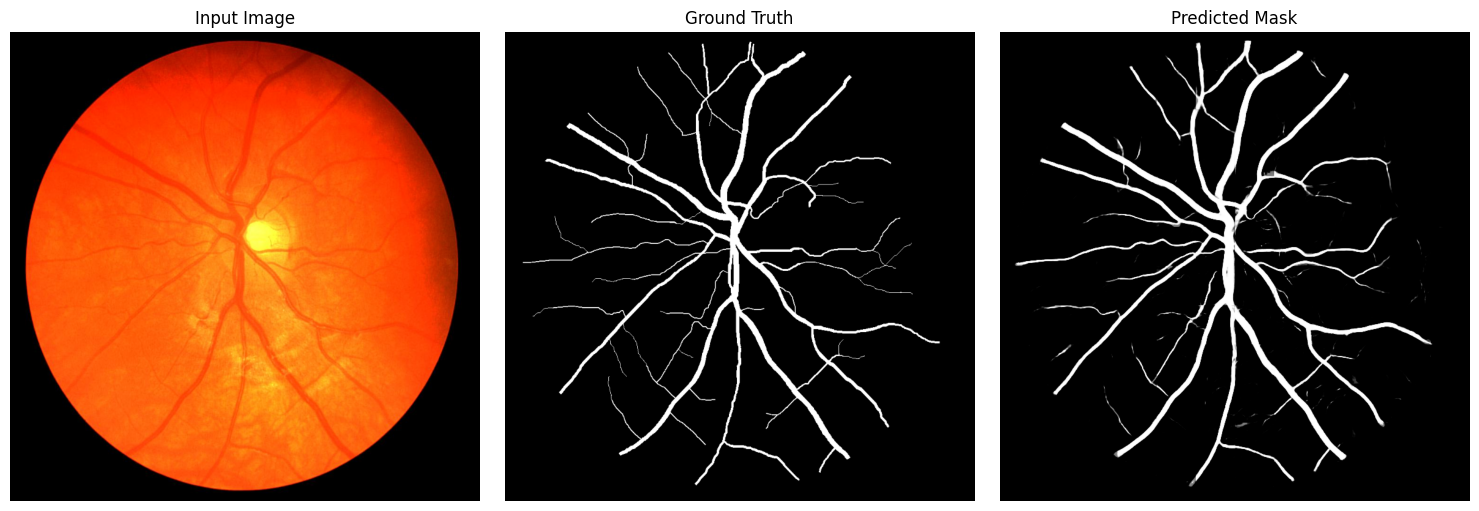

In [29]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

#================= CONSTANTS =================

RESIZE_SIZE = 768   # Full image resize
IMG_SIZE    = 128   # Patch size
OVERLAP     = 0.5   # 50% overlap
THRESHOLD   = 0.5   # Binarization threshold
BATCH_SIZE  = 16    # Mini-batch size for patch prediction

#================= PATCH FUNCTIONS =================

def extract_patches(img, patch_size=IMG_SIZE, overlap=OVERLAP):
    stride = int(patch_size * (1 - overlap))
    H, W = img.shape[:2]
    patches = []
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            patches.append(img[y:y+patch_size, x:x+patch_size])
    return patches

def stitch_patches(patches, image_size=RESIZE_SIZE, patch_size=IMG_SIZE, overlap=OVERLAP):
    stride = int(patch_size * (1 - overlap))
    stitched_mask = np.zeros((image_size, image_size), dtype=np.float32)
    count_mask = np.zeros((image_size, image_size), dtype=np.float32)

    idx = 0  
    for y in range(0, image_size - patch_size + 1, stride):  
        for x in range(0, image_size - patch_size + 1, stride):  
            stitched_mask[y:y+patch_size, x:x+patch_size] += patches[idx]  
            count_mask[y:y+patch_size, x:x+patch_size] += 1  
            idx += 1  

    stitched_mask /= count_mask  
    return np.clip(stitched_mask, 0, 1)

#================= FULL IMAGE PREDICTION =================

def predict_full_image(attention_unet_model, img_path, batch_size=BATCH_SIZE):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (RESIZE_SIZE, RESIZE_SIZE))

    patches = extract_patches(img)  
    pred_patches = []  

    # Predict in mini-batches  
    for i in range(0, len(patches), batch_size):  
        batch = np.array([p.astype(np.float32)/255.0 for p in patches[i:i+batch_size]])  
        preds = attention_unet_model.predict(batch, verbose=0)  
        pred_patches.extend([p[:, :, 0] for p in preds])  # remove channel dim  

    full_mask = stitch_patches(pred_patches)  
    return img, full_mask

#================= EVALUATION FUNCTION =================

def evaluate_model(attention_unet_model, image_paths, mask_paths):
    dice_list, iou_list, acc_list, f1_list, sens_list, spec_list = [], [], [], [], [], []

    for img_path, mask_path in zip(image_paths, mask_paths):  
        img, pred_mask = predict_full_image(attention_unet_model, img_path)  

        gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  
        gt_mask = cv2.resize(gt_mask, (RESIZE_SIZE, RESIZE_SIZE)) / 255.0  

        pred_bin = (pred_mask >= THRESHOLD).astype(np.float32)  
        gt_bin   = (gt_mask >= 0.5).astype(np.float32)  

        intersection = np.sum(pred_bin * gt_bin)  
        union = np.sum(pred_bin) + np.sum(gt_bin) - intersection  
        dice = (2 * intersection) / (np.sum(pred_bin) + np.sum(gt_bin) + 1e-7)  
        iou  = intersection / (union + 1e-7)  
        acc  = accuracy_score(gt_bin.flatten(), pred_bin.flatten())  
        f1   = f1_score(gt_bin.flatten(), pred_bin.flatten())  
        sens = recall_score(gt_bin.flatten(), pred_bin.flatten())  
        spec = (np.sum((1 - gt_bin) * (1 - pred_bin)) / np.sum(1 - gt_bin))  

        dice_list.append(dice)  
        iou_list.append(iou)  
        acc_list.append(acc)  
        f1_list.append(f1)  
        sens_list.append(sens)  
        spec_list.append(spec)  

    print(f"Mean Dice        : {np.mean(dice_list):.4f}")  
    print(f"Mean IoU         : {np.mean(iou_list):.4f}")  
    print(f"Mean Accuracy    : {np.mean(acc_list):.4f}")  
    print(f"Mean F1 Score    : {np.mean(f1_list):.4f}")  
    print(f"Mean Sensitivity : {np.mean(sens_list):.4f}")  
    print(f"Mean Specificity : {np.mean(spec_list):.4f}")

#================= VISUALIZATION =================

def visualize_prediction(attention_unet_model, img_path, mask_path):
    img, pred_mask = predict_full_image(attention_unet_model, img_path)
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.resize(gt_mask, (RESIZE_SIZE, RESIZE_SIZE)) / 255.0

    plt.figure(figsize=(15,5))  
    plt.subplot(1,3,1)  
    plt.imshow(img)  
    plt.title("Input Image")  
    plt.axis("off")  

    plt.subplot(1,3,2)  
    plt.imshow(gt_mask, cmap="gray")  
    plt.title("Ground Truth")  
    plt.axis("off")  

    plt.subplot(1,3,3)  
    plt.imshow(pred_mask, cmap="gray")  
    plt.title("Predicted Mask")  
    plt.axis("off")  

    plt.tight_layout()  
    plt.show()

#================= USAGE =================

# Evaluate all test images
evaluate_model(attention_unet_model, test_images, test_masks)

# Visualize first test image
visualize_prediction(attention_unet_model, test_images[0], test_masks[0])


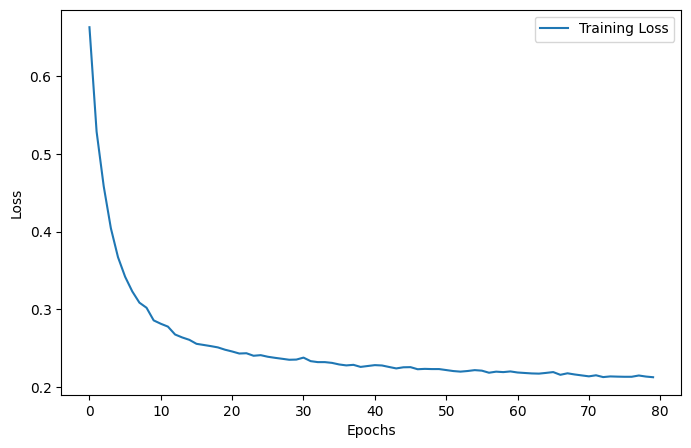

In [30]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [28]:
from tensorflow.keras import backend as K

# Clear any previous models and free memory
K.clear_session()
